# Tutorial: Checando os pressupostos da Regressão Linear

**Dataset:** altura de árvores em função de diâmetro (e espécie)

Rode célula por célula e vá interpretando cada saída antes de seguir para a próxima etapa.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

## 1. Carregar e conferir os dados

In [4]:
df = pd.read_excel("C:\\Users\\User\\Downloads\\arvore2.xlsx")  # ajuste o caminho/nome do arquivo

print(df.head())
print(df.info())
print(df.describe())

# Confira se 'especie' (0/1) bate com os nomes científicos distintos.
# Cuidado com espaços extras ou pequenas variações de grafia no nome!
print(df.groupby("especie")["Nomecientifico"].unique())

              Nomecientifico  diametro_cm  altura_m  especie
0  Sebastiania commersoniana         52.2      15.2        0
1  Sebastiania commersoniana         95.0      17.3        0
2  Sebastiania commersoniana         67.3      16.3        0
3  Sebastiania commersoniana         46.3      14.0        0
4  Sebastiania commersoniana         64.1      15.0        0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Nomecientifico  105 non-null    object 
 1   diametro_cm     105 non-null    float64
 2   altura_m        105 non-null    float64
 3   especie         105 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 3.4+ KB
None
       diametro_cm    altura_m     especie
count   105.000000  105.000000  105.000000
mean     77.876190   16.572381    0.352381
std      26.380177    2.141867    0.480003
min      30.500000   

## 2. Análise Exploratória (EDA)

        diametro_cm                                                          \
              count       mean        std   min     25%    50%   75%    max   
especie                                                                       
0              68.0  80.588235  24.111362  34.5  59.675  80.15  96.5  127.5   
1              37.0  72.891892  29.816433  30.5  52.500  64.90  85.7  161.0   

        altura_m                                                     
           count       mean       std   min   25%   50%   75%   max  
especie                                                              
0           68.0  17.300000  1.935605  14.0  16.0  17.1  18.6  22.0  
1           37.0  15.235135  1.855355  11.7  13.6  15.4  17.0  17.9  


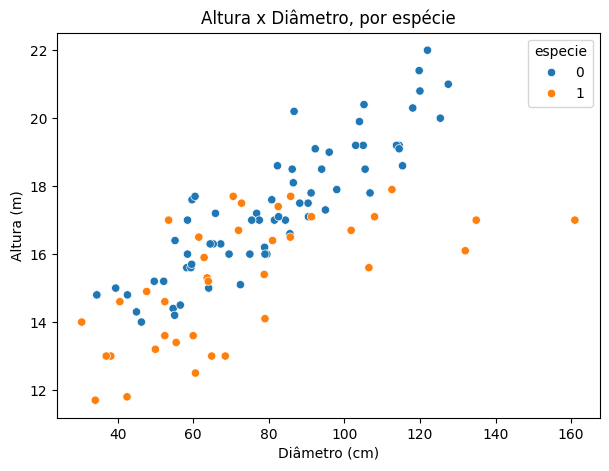

In [5]:
print(df.groupby("especie")[["diametro_cm", "altura_m"]].describe())

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="diametro_cm", y="altura_m", hue="especie")
plt.title("Altura x Diâmetro, por espécie")
plt.xlabel("Diâmetro (cm)")
plt.ylabel("Altura (m)")
plt.show()
# Pergunta: a nuvem de pontos parece seguir uma RETA, ou tem uma
# curvatura (ex.: a altura "achata" quando o diâmetro cresce)?
# As duas espécies parecem seguir a MESMA tendência ou tendências diferentes?

## 3. Ajustar o modelo (regressão linear simples)

In [6]:
modelo = smf.ols("altura_m ~ diametro_cm", data=df).fit()
print(modelo.summary())
# Observe: R², coeficiente (inclinação), p-valor, intervalo de confiança.

                            OLS Regression Results                            
Dep. Variable:               altura_m   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     136.3
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           1.46e-20
Time:                        20:51:46   Log-Likelihood:                -184.21
No. Observations:                 105   AIC:                             372.4
Df Residuals:                     103   BIC:                             377.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      11.8008      0.431     27.356      

## 4. Checar linearidade e homocedasticidade

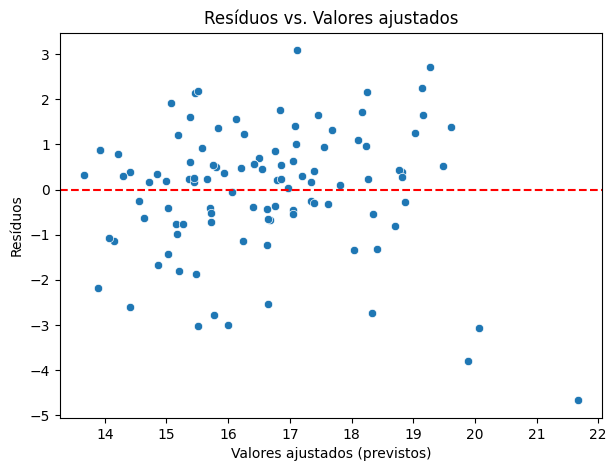

{'LM stat': 11.730024723793024, 'LM p-value': 0.0006149977552159652, 'F stat': 12.953713592962528, 'F p-value': 0.0004926995467631106}


In [7]:
fitted = modelo.fittedvalues
residuos = modelo.resid

plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted, y=residuos)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valores ajustados (previstos)")
plt.ylabel("Resíduos")
plt.title("Resíduos vs. Valores ajustados")
plt.show()
# O que procurar: os pontos devem estar espalhados aleatoriamente em
# torno de zero, sem formar uma curva (não linearidade) nem um "funil"
# que abre ou fecha (heterocedasticidade).

# Teste formal de heterocedasticidade (Breusch-Pagan)
bp_test = het_breuschpagan(residuos, modelo.model.exog)
labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print(dict(zip(labels, bp_test)))
# p-valor baixo (< 0.05) sugere heterocedasticidade (violação do pressuposto)

## 5. Checar normalidade dos resíduos

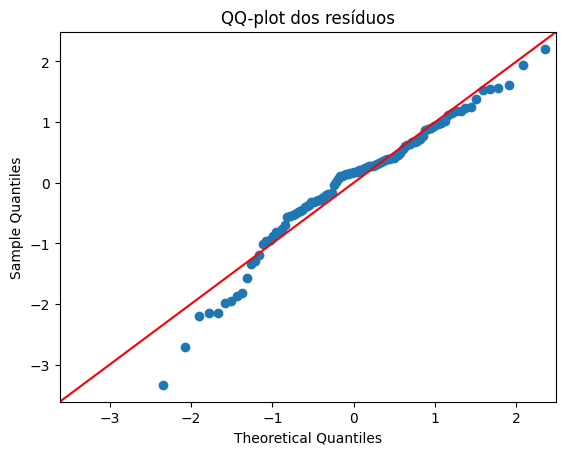

Shapiro-Wilk: estatística=0.9620, p-valor=0.0042


In [8]:
sm.qqplot(residuos, line="45", fit=True)
plt.title("QQ-plot dos resíduos")
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"Shapiro-Wilk: estatística={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}")
# p-valor baixo (< 0.05) sugere que os resíduos NÃO seguem normal

## 6. Checar independência dos resíduos (relevante p/ dados sequenciais/temporais)

In [9]:
dw = durbin_watson(residuos)
print(f"Durbin-Watson: {dw:.3f}")
# Próximo de 2 = sem autocorrelação. Longe de 2 (perto de 0 ou 4) = autocorrelação.
# Obs.: para dados de árvores medidas de forma independente (não em série
# temporal), esse teste é menos crítico, mas vale entender o que ele mede.

Durbin-Watson: 1.377


## 7. Outliers e pontos de alta influência

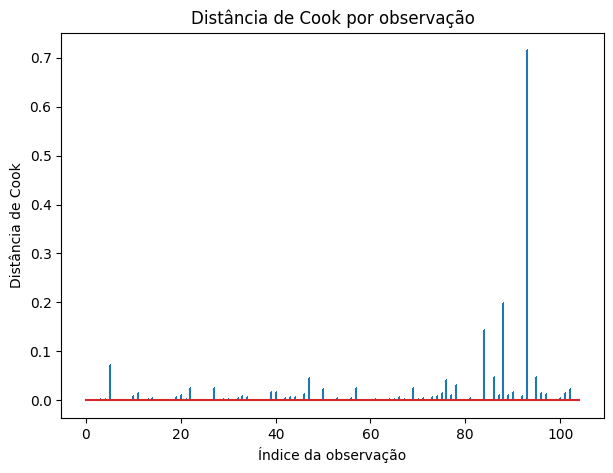

In [10]:
influence = modelo.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(7, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.title("Distância de Cook por observação")
plt.xlabel("Índice da observação")
plt.ylabel("Distância de Cook")
plt.show()
# Regra prática comum: valores de Cook's D muito acima de 4/n merecem
# investigação (pode ser um ponto influenciando demais o modelo).

## 8. O papel da variável categórica 'especie'

In [11]:
# Modelo com espécie como variável dummy (intercepto diferente por espécie)
modelo_especie = smf.ols("altura_m ~ diametro_cm + C(especie)", data=df).fit()
print(modelo_especie.summary())

                            OLS Regression Results                            
Dep. Variable:               altura_m   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     118.7
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           2.33e-27
Time:                        20:51:46   Log-Likelihood:                -165.33
No. Observations:                 105   AIC:                             336.7
Df Residuals:                     102   BIC:                             344.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          12.6959      0.386     

In [12]:
# Modelo com termo de interação (inclinação diferente por espécie)
modelo_interacao = smf.ols(
    "altura_m ~ diametro_cm * C(especie)", data=df
).fit()
print(modelo_interacao.summary())

# Compare os R² ajustados e os p-valores dos termos de espécie/interação
# entre os três modelos (simples, com dummy, com interação) para decidir
# se a espécie realmente muda a relação diâmetro-altura.

                            OLS Regression Results                            
Dep. Variable:               altura_m   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     93.99
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           4.08e-29
Time:                        20:51:46   Log-Likelihood:                -158.49
No. Observations:                 105   AIC:                             325.0
Df Residuals:                     101   BIC:                             335.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## 9. Multicolinearidade (relevante quando há 2+ variáveis independentes)

In [13]:
X = modelo_interacao.model.exog
vif = pd.DataFrame()
vif["variavel"] = modelo_interacao.model.exog_names
vif["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
print(vif)
# VIF > 5 (ou 10, dependendo da referência que você seguir) indica
# multicolinearidade preocupante entre as variáveis.

                      variavel       VIF
0                    Intercept  1.000000
1              C(especie)[T.1]  8.973282
2                  diametro_cm  1.858106
3  diametro_cm:C(especie)[T.1]  9.068275
